## Boxplot and Violin plot

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
kohli = np.loadtxt(r"C:\Users\heet5\Downloads\batting\kohli.txt")
sachin = np.loadtxt(r"C:\Users\heet5\Downloads\batting\sachin.txt")
sehwag = np.loadtxt(r"C:\Users\heet5\Downloads\batting\sehwag.txt")

In [85]:
kohli.shape, sachin.shape, sehwag.shape

((290,), (452,), (245,))

Text(0.5, 1.0, 'Boxplots of each batsman')

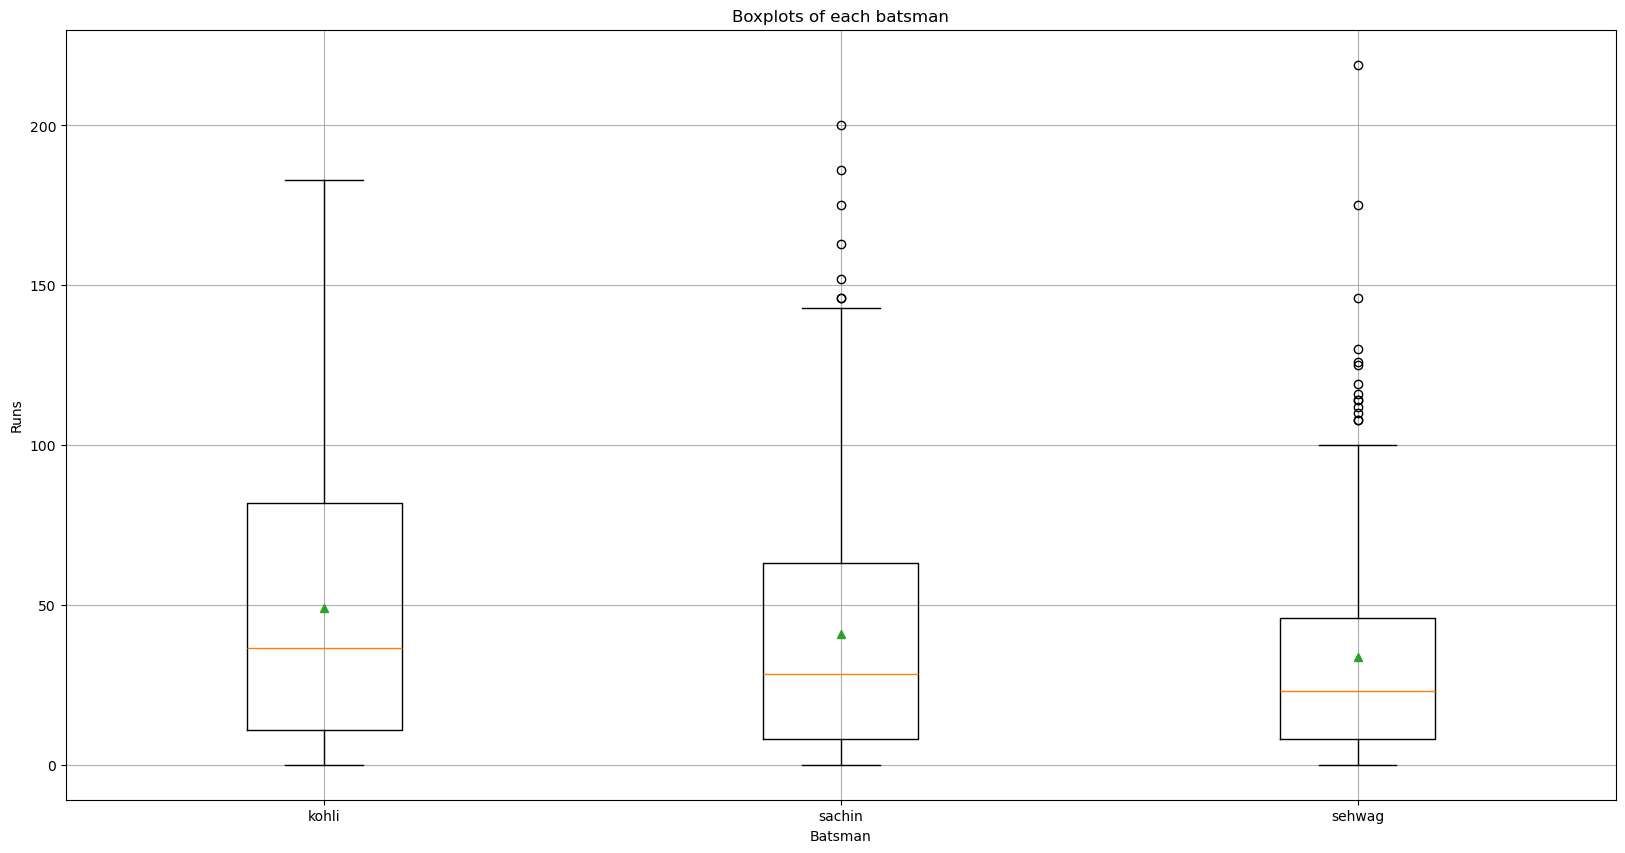

In [176]:
fig,ax = plt.subplots(figsize=(20,10))
ax.boxplot((kohli,sachin,sehwag),showmeans=True)
ax.set_xticks([1,2,3],['kohli','sachin','sehwag'])
ax.grid()
ax.set_xlabel("Batsman")
ax.set_ylabel("Runs")
ax.set_title("Boxplots of each batsman")

In [145]:
kohli_q1, kohli_q2, kohli_q3 = np.percentile(kohli,[25,50,75])
sachin_q1, sachin_q2, sachin_q3 = np.percentile(sachin,[25,50,75])
sehwag_q1, sehwag_q2, sehwag_q3 = np.percentile(sehwag,[25,50,75])

kohli_iqr = kohli_q3 - kohli_q1
sachin_iqr = sachin_q3 - sachin_q1
sehwag_iqr = sehwag_q3 - sehwag_q1

In [146]:
kohli_iqr,sachin_iqr,sehwag_iqr

(70.75, 55.0, 38.0)

Text(0.5, 1.0, 'Violin plots of each Batsman')

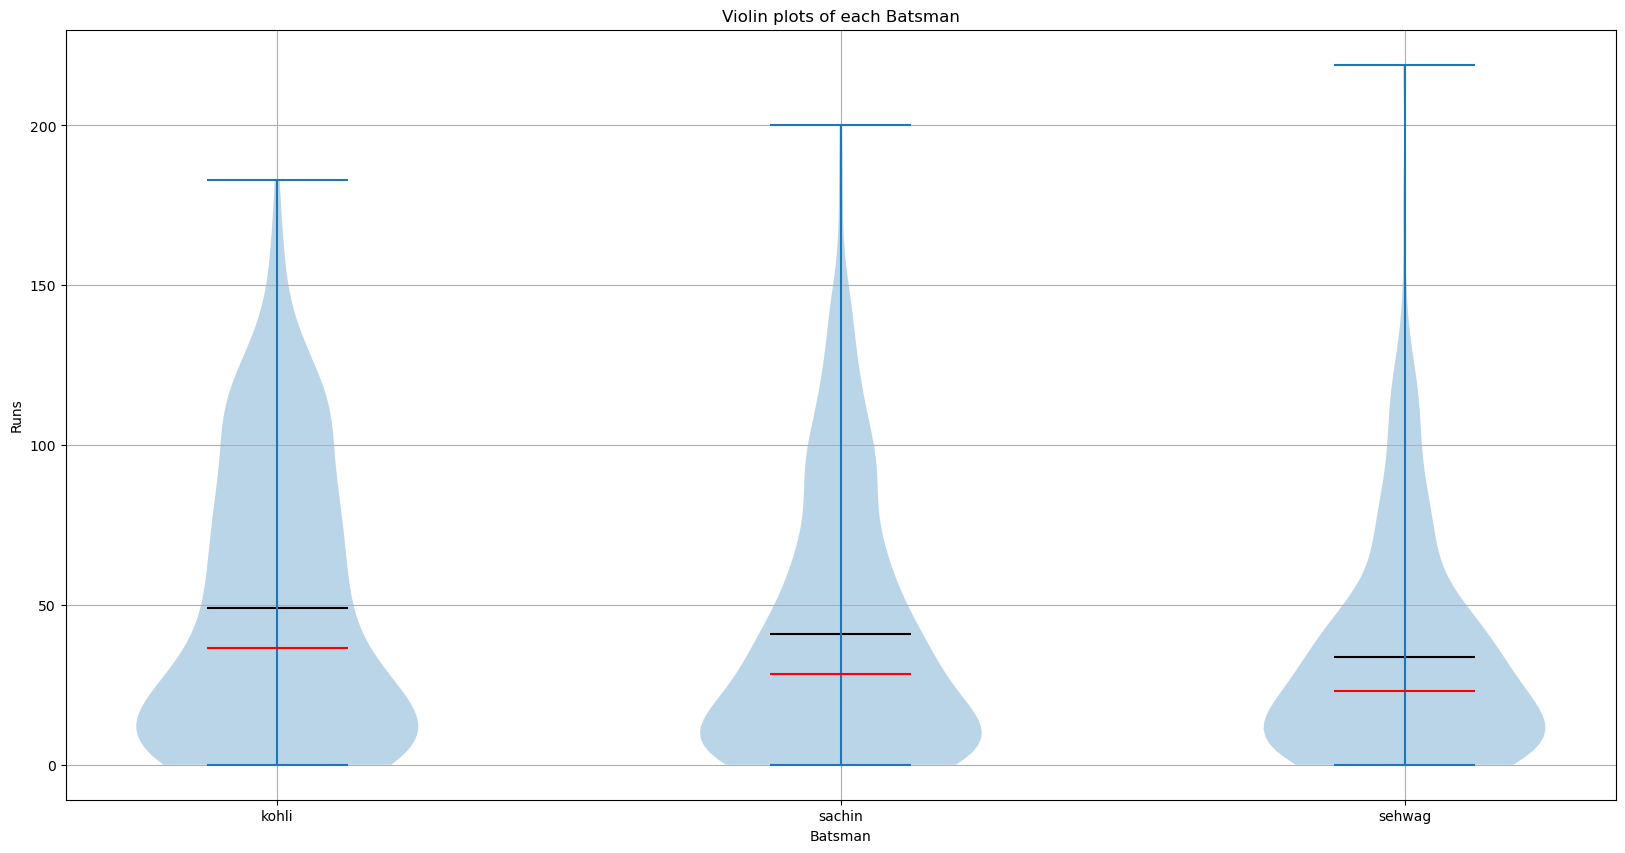

In [173]:
fig,ax = plt.subplots(figsize=(20,10))
player_violin = ax.violinplot((kohli,sachin,sehwag),showmeans=True,showmedians=True)
ax.set_xticks([1,2,3],['kohli','sachin','sehwag'])
ax.grid()

# median with red line and mean with black line
player_violin['cmedians'].set_edgecolor('red') 
player_violin['cmeans'].set_edgecolor('black')

ax.set_xlabel("Batsman")
ax.set_ylabel("Runs")
ax.set_title("Violin plots of each Batsman")


### Mean and Std

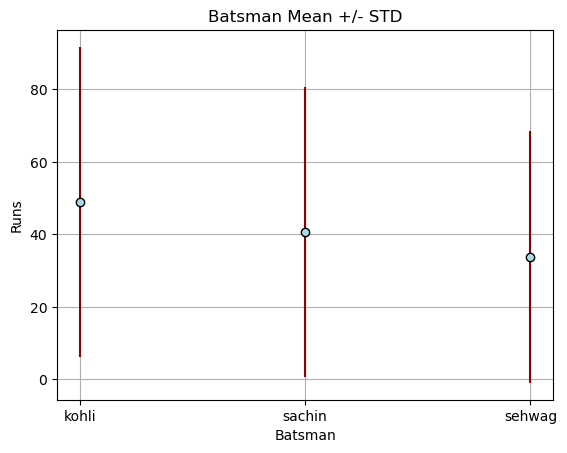

In [178]:
plt.errorbar(['kohli','sachin','sehwag'],[np.mean(kohli), np.mean(sachin), np.mean(sehwag)],
             yerr= [np.std(kohli), np.std(sachin), np.std(sehwag)],fmt='o',ecolor='#8B0000',color='#ADD8E6',mec='black')
plt.title('Batsman Mean +/- STD')
plt.xlabel('Batsman')
plt.ylabel('Runs')
plt.grid()

### Median and IQR 

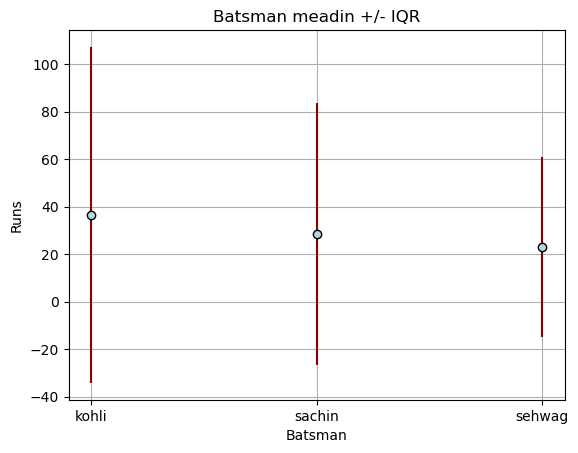

In [177]:
plt.errorbar(['kohli','sachin','sehwag'],[kohli_q2, sachin_q2, sehwag_q2],
             yerr= [kohli_iqr, sachin_iqr, sehwag_iqr],fmt='o',ecolor='#8B0000',color='#ADD8E6',mec='black')
plt.title('Batsman meadin +/- IQR')
plt.xlabel('Batsman')
plt.ylabel('Runs')
plt.grid()

# 

# Histograms

Text(0.5, 0, 'Runs')

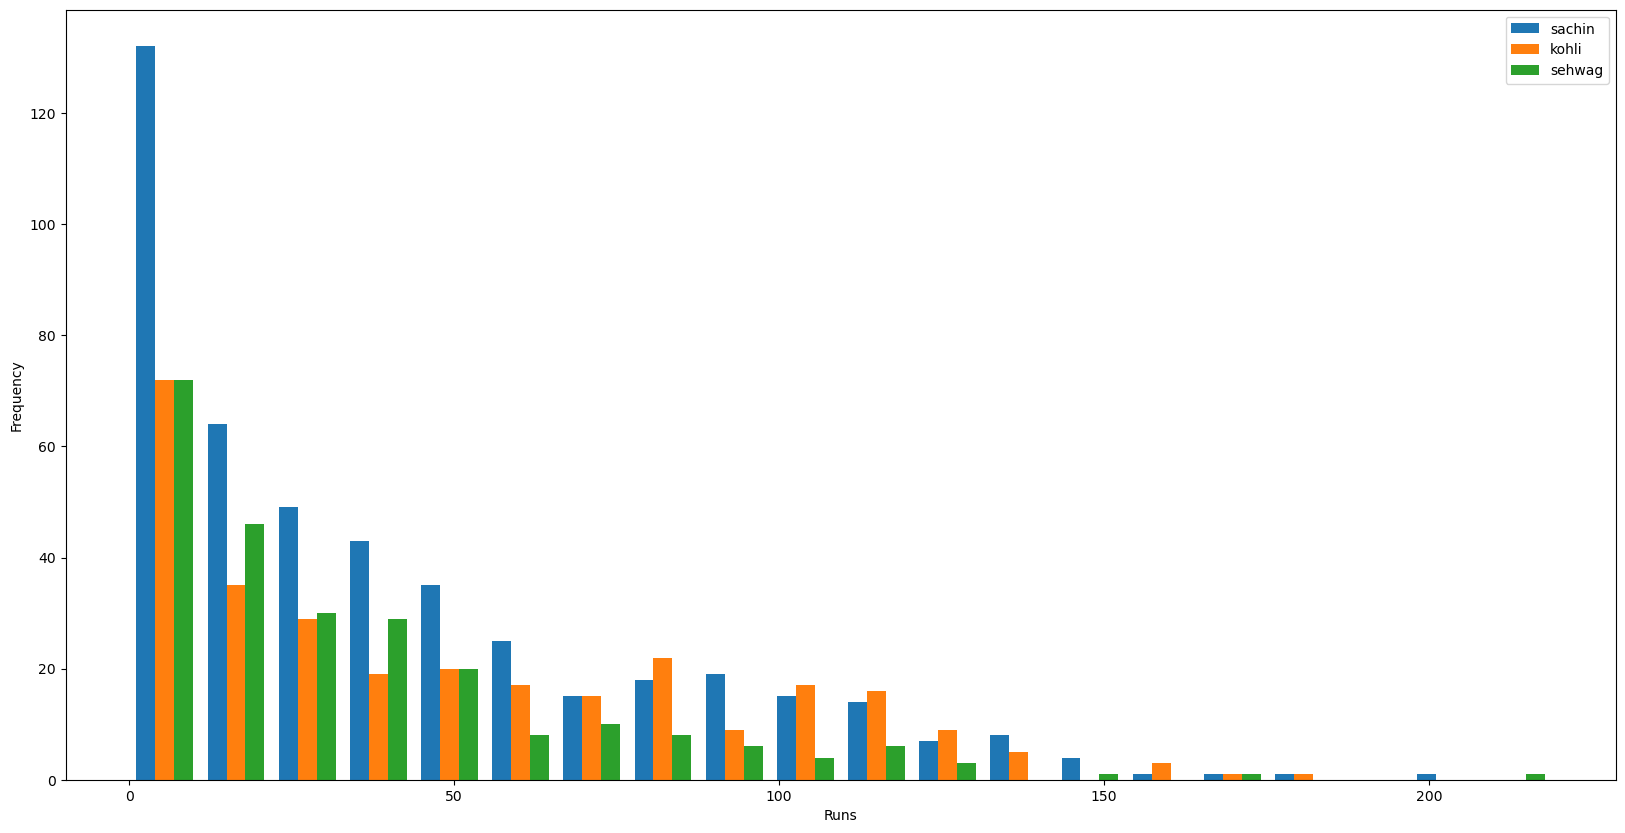

In [94]:
plt.figure(figsize=(20,10))
plt.hist(( sachin, kohli, sehwag), bins='auto')
plt.legend(['sachin', 'kohli', 'sehwag'])
plt.ylabel('Frequency')
plt.xlabel('Runs')

#

### Kohli

Text(0, 0.5, 'Density= probability / binwidth')

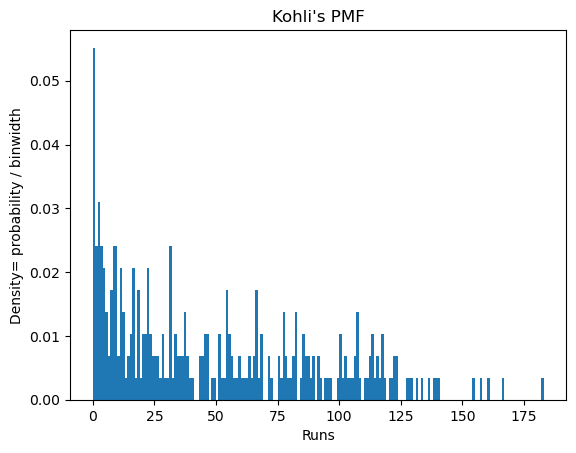

In [140]:
plt.figure()
kohli_density, bin_edge, patche = plt.hist(kohli,density=True,bins= int( kohli.max())) 
plt.title("Kohli's PMF")
plt.xlabel("Runs")
plt.ylabel("Density= probability / binwidth")

In [150]:
kohli_binwidth = bin_edge[1] - bin_edge[0]
print("binwidth =",kohli_binwidth)
print('kohli_density =', kohli_density)

binwidth = 1.0
kohli_density = [0.05517241 0.02413793 0.03103448 0.02413793 0.02068966 0.0137931
 0.00689655 0.01724138 0.02413793 0.02413793 0.00689655 0.02068966
 0.0137931  0.00344828 0.00689655 0.01034483 0.02068966 0.00344828
 0.01724138 0.00344828 0.01034483 0.01034483 0.02068966 0.01034483
 0.00689655 0.00689655 0.00689655 0.00344828 0.01034483 0.00344828
 0.00344828 0.02413793 0.00344828 0.01034483 0.00689655 0.00689655
 0.00689655 0.0137931  0.00689655 0.00344828 0.00344828 0.
 0.         0.00689655 0.00689655 0.01034483 0.01034483 0.
 0.00344828 0.00344828 0.         0.01034483 0.00344828 0.00344828
 0.01724138 0.01034483 0.00689655 0.00344828 0.00344828 0.00689655
 0.00344828 0.00344828 0.00344828 0.00689655 0.00344828 0.00689655
 0.01724138 0.00344828 0.01034483 0.         0.         0.00689655
 0.00344828 0.         0.         0.00689655 0.00344828 0.0137931
 0.00689655 0.00344828 0.00344828 0.00689655 0.0137931  0.
 0.00344828 0.01034483 0.00689655 0.00689655 0.00344828 0

#### The probability of a variable being greater than a specific value is the area under the PDF from that value to infinity. 
#### Which is the sum of the densities for all values in that range, multiplied by the bin width

### 

#### probability of atleast 50 runs( 50/1 = 50 )

In [153]:
sum(kohli_density[50:])*(kohli_binwidth)

0.4310344827586211

#### probability of atleast 100 runs( 100/1 = 100 )

In [143]:
sum(kohli_density[100:])*(kohli_binwidth)

0.17586206896551734

#### probability of atleast 10 runs( 10/1 = 10 )

In [144]:
sum(kohli_density[10:])*(kohli_binwidth)

0.7586206896551734

#### The conditional probability that a batsman scores 50 or more given they have crossed 10 is calculated as the probability of scoring at least 50 divided by the probability of scoring at least 10, expressed as $P(S \ge 50 \mid S \ge 10) = \frac{P(S \ge 50)}{P(S \ge 10)}$.

In [126]:
(sum(kohli_density[50:])*(kohli_binwidth)) / (sum(kohli_density[10:])*(kohli_binwidth))

0.568181818181818

### 

### Sachin

Text(0, 0.5, 'Density= probability / binwidth')

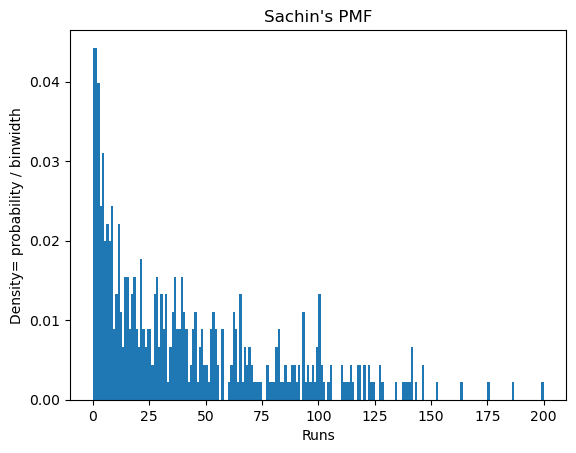

In [127]:
plt.figure()
sachin_density, bin_edge, patche = plt.hist(sachin,density=True,bins=int( sachin.max() )) 
plt.title("Sachin's PMF")
plt.xlabel("Runs")
plt.ylabel("Density= probability / binwidth")

In [128]:
sachin_binwidth = bin_edge[1] - bin_edge[0]
print("binwidth =",sachin_binwidth)
print('kohli_density =', sachin_density)

binwidth = 1.0
kohli_density = [0.04424779 0.04424779 0.03982301 0.02433628 0.03097345 0.0199115
 0.02212389 0.0199115  0.02433628 0.00884956 0.01327434 0.02212389
 0.01106195 0.00663717 0.01548673 0.01548673 0.00884956 0.01327434
 0.01548673 0.00884956 0.00663717 0.01769912 0.00884956 0.00663717
 0.00884956 0.00884956 0.00442478 0.01327434 0.01548673 0.00663717
 0.01327434 0.00884956 0.01327434 0.00221239 0.00663717 0.01106195
 0.01548673 0.00884956 0.00884956 0.01548673 0.01106195 0.00884956
 0.00221239 0.00442478 0.00884956 0.01106195 0.00221239 0.00663717
 0.00884956 0.00442478 0.00442478 0.00221239 0.00884956 0.01106195
 0.00884956 0.00442478 0.         0.00884956 0.         0.
 0.00221239 0.00442478 0.01106195 0.00884956 0.00221239 0.01327434
 0.00221239 0.00663717 0.00442478 0.00663717 0.00442478 0.00221239
 0.00221239 0.00221239 0.00221239 0.         0.         0.00442478
 0.00221239 0.00221239 0.00221239 0.00663717 0.00884956 0.00221239
 0.00221239 0.00442478 0.00221239 0.0022

#### probability of atleast 50 runs( 50/1 = 50 )

In [129]:
sum(sachin_density[50:])*(sachin_binwidth)

0.32079646017699137

#### probability of atleast 100 runs( 100/1 = 100 )

In [130]:
sum(sachin_density[100:])*(sachin_binwidth)

0.10840707964601773

#### probability of atleast 10 runs( 10/1 = 10 )

In [131]:
sum(sachin_density[10:])*(sachin_binwidth)

0.7212389380530958

#### $P(S \ge 50 \mid S \ge 10) = \frac{P(S \ge 50)}{P(S \ge 10)}$

In [132]:
(sum(sachin_density[50:])*(sachin_binwidth)) / (sum(sachin_density[10:])*(sachin_binwidth))

0.4447852760736209

### 

### Sehwag

Text(0, 0.5, 'Density= probability / binwidth')

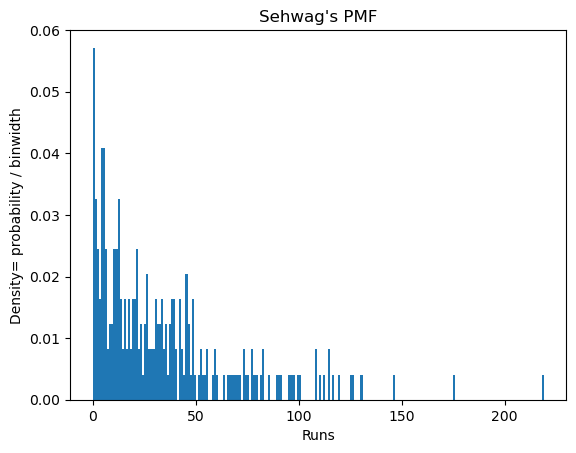

In [133]:
plt.figure()
sehwag_density, bin_edge, patche = plt.hist(sehwag,density=True,bins=int(sehwag.max())) 
plt.title("Sehwag's PMF")
plt.xlabel("Runs")
plt.ylabel("Density= probability / binwidth")

In [134]:
sehwag_binwidth = bin_edge[1] - bin_edge[0]
print("binwidth =",sehwag_binwidth)
print('Sehwag_density =', sehwag_density)

binwidth = 1.0
Sehwag_density = [0.05714286 0.03265306 0.0244898  0.01632653 0.04081633 0.04081633
 0.0244898  0.00816327 0.0122449  0.0122449  0.0244898  0.0244898
 0.03265306 0.01632653 0.00816327 0.01632653 0.00816327 0.01632653
 0.00816327 0.01632653 0.01632653 0.0244898  0.00816327 0.0122449
 0.00408163 0.0122449  0.02040816 0.00816327 0.00816327 0.00816327
 0.01632653 0.0122449  0.0122449  0.01632653 0.00816327 0.0122449
 0.00408163 0.0122449  0.01632653 0.01632653 0.00816327 0.
 0.01632653 0.00816327 0.00408163 0.02040816 0.0122449  0.00408163
 0.01632653 0.00408163 0.         0.00408163 0.00816327 0.00408163
 0.00408163 0.00816327 0.         0.         0.00408163 0.00816327
 0.00408163 0.         0.         0.00408163 0.         0.00408163
 0.00408163 0.00408163 0.00408163 0.00408163 0.00408163 0.00408163
 0.         0.00816327 0.00408163 0.00408163 0.         0.00816327
 0.00408163 0.00408163 0.         0.00408163 0.00816327 0.
 0.         0.00408163 0.         0.         0.  

#### probability of atleast 50 runs( 50/1 = 50 )

In [135]:
sum(sehwag_density[50:])*(sehwag_binwidth)

0.21632653061224477

#### probability of atleast 100 runs( 100/1= 100 )

In [136]:
sum(sehwag_density[100:])*(sehwag_binwidth)

0.06122448979591837

#### probability of atleast 10 runs( 10/1 = 10 )

In [137]:
sum(sehwag_density[10:])*(sehwag_binwidth)

0.7306122448979608

#### $P(S \ge 50 \mid S \ge 10) = \frac{P(S \ge 50)}{P(S \ge 10)}$

In [138]:
(sum(sehwag_density[50:])*(sehwag_binwidth)) / (sum(sehwag_density[10:])*(sehwag_binwidth))

0.29608938547485947

## 

In [168]:
# Make table
data = {
    "Batsman": ["Kohli", "Sachin", "Sehwag"],
    "Matches" : [len(kohli), len(sachin), len(sehwag)],
    "Maximum" : [kohli.max(), sachin.max(), sehwag.max()],
    "Median": [kohli_q2, sachin_q2, sehwag_q2],
    "Mean": [np.mean(kohli), np.mean(sachin), np.mean(sehwag)],
    "STD" : [np.std(kohli), np.std(sachin), np.std(sehwag)],
    "Q1 (25%)": [kohli_q1, sachin_q1, sehwag_q1],
    "Q3 (75%)": [kohli_q3, sachin_q3, sehwag_q3],
    "IQR": [kohli_iqr, sachin_iqr, sehwag_iqr],
    "P(≥50)": [0.431, 0.321, 0.216],
    "P(≥100)": [0.176, 0.108, 0.0612],
    "P(50 | ≥10)": [0.568, 0.445, 0.296]
}
df=pd.DataFrame(data)

In [169]:
df=df.round(3)

In [170]:
df

,Batsman,Matches,Maximum,Median,Mean,STD,Q1 (25%),Q3 (75%),IQR,P(≥50),P(≥100),P(50 | ≥10)
0,Kohli,290,183.0,36.5,48.900,42.835,11.0,81.75,70.75,0.431,0.176,0.568
1,Sachin,452,200.0,28.5,40.765,39.995,8.0,63.00,55.00,0.321,0.108,0.445
2,Sehwag,245,219.0,23.0,33.767,34.738,8.0,46.00,38.00,0.216,0.061,0.296


#### From above table we can see that kohli's mean,meadin, Q1 and Q3 are highest
#### His probability of scoring 50 and 100 is also highest and if he score greater than or equal to 10 run then his probability of scoring 50 is 56% which is increadible.
#### So I chose VIRAT KOHLI in my team